# Quasi-Newton inference for non-conjugate GPs

Quasi-Newton (QN) inference reaches the **same Laplace approximation** as `LaplaceInference`, but takes a different optimization path to get there.

- **Laplace**: full Newton iteration. Each step requires the per-point Hessian *and* a Cholesky solve on $K + \mathrm{diag}(1/\Lambda)$. Cost per iter: $O(N^3)$. Convergence: 5–10 iterations on log-concave likelihoods.
- **Quasi-Newton**: optimize the MAP via [L-BFGS](https://docs.kidger.site/optax/api/optimizers/#optax.lbfgs). Each step uses **only the gradient** of the (negative) log posterior; the Hessian is approximated implicitly via a low-rank update from the recent gradient history. Cost per iter: $O(N^2)$ (one Cholesky solve against the *prior* Cholesky, computed once). Convergence: typically 30–100 iterations.

At convergence both strategies report the **exact** Laplace covariance — the same Gaussian approximation. The trade-off is:

| | Laplace | Quasi-Newton |
|---|---|---|
| Per-iter cost | $O(N^3)$ | $O(N^2)$ + amortized $O(N^3)$ for prior Cholesky |
| Iterations to converge | 5–10 | 30–100 |
| Total cost | $\sim 10\, N^3$ | $\sim N^3 + 100\,N^2$ |
| Crossover where QN wins | $N^2 \gtrsim 100\,N^3 / 10$, i.e. when **prior solves dominate** | |

In practice QN is the right choice when (a) $N$ is in the thousands so the per-iteration $N^3$ cost of Newton is the bottleneck, and (b) you can use an iterative prior solver (CG, BBMM via `gaussx`) so the $O(N^2)$ matvec replaces the dense factorization.

**Caveat.** L-BFGS doesn't always converge cleanly to high precision — heavy-tail likelihoods and ill-conditioned priors cause it to plateau short of the optimum. If QN reports `converged=False`, the result is still a Gaussian approximation centered at the L-BFGS iterate (with exact Hessian there), but it's not at the true MAP and won't match Laplace bit-for-bit. Always check `cond.converged`.

In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from pyrox.gp import (
    RBF,
    BernoulliLikelihood,
    GPPrior,
    LaplaceInference,
    QuasiNewtonInference,
)


plt.rcParams["figure.dpi"] = 110
key = jax.random.PRNGKey(0)

/home/azureuser/localfiles/pyrox/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Bernoulli classification — Laplace vs Quasi-Newton

We expect the same posterior at convergence. The difference is only in the optimization path.

In [2]:
N = 60
X = jnp.linspace(-3.0, 3.0, N)[:, None]
f_true = 2.0 * jnp.sin(X[:, 0]) + 0.4 * X[:, 0]
probs_true = jax.nn.sigmoid(f_true)
y = (jax.random.uniform(key, (N,)) < probs_true).astype(jnp.float32)

prior = GPPrior(kernel=RBF(init_lengthscale=0.6, init_variance=1.5), X=X)
lik = BernoulliLikelihood()

cond_lap = LaplaceInference(max_iter=50).fit(prior, lik, y)
cond_qn = QuasiNewtonInference(max_iter=200, tol=1e-5).fit(prior, lik, y)

print(
    f"Laplace        iters={cond_lap.n_iter:3d}  conv={cond_lap.converged}  log_marg≈{float(cond_lap.log_marginal_approx):.3f}"
)
print(
    f"Quasi-Newton   iters={cond_qn.n_iter:3d}  conv={cond_qn.converged}  log_marg≈{float(cond_qn.log_marginal_approx):.3f}"
)
print()
print(
    f"max |q_mean diff|: {float(jnp.max(jnp.abs(cond_lap.q_mean - cond_qn.q_mean))):.3e}"
)
print(
    f"max |q_var  diff|: {float(jnp.max(jnp.abs(cond_lap.q_var - cond_qn.q_var))):.3e}"
)

Laplace        iters=  6  conv=True  log_marg≈-25.691
Quasi-Newton   iters=200  conv=False  log_marg≈-25.692

max |q_mean diff|: 4.292e-06
max |q_var  diff|: 1.125e-03


**Reading the numbers:** if QN converged, the posterior should match Laplace to L-BFGS's tolerance. The number of iterations is much higher (typically 5–20× more), but each iteration is cheaper. The reported `log_marg` should be within numerical noise of Laplace's.

## Convergence trace — why L-BFGS takes more iterations

Newton's method has quadratic convergence on log-concave problems: error squares each step. L-BFGS has only superlinear convergence (somewhere between linear and quadratic), so iteration counts are inherently higher. The flip side: each L-BFGS step is *much* cheaper because we never solve the full Hessian system.

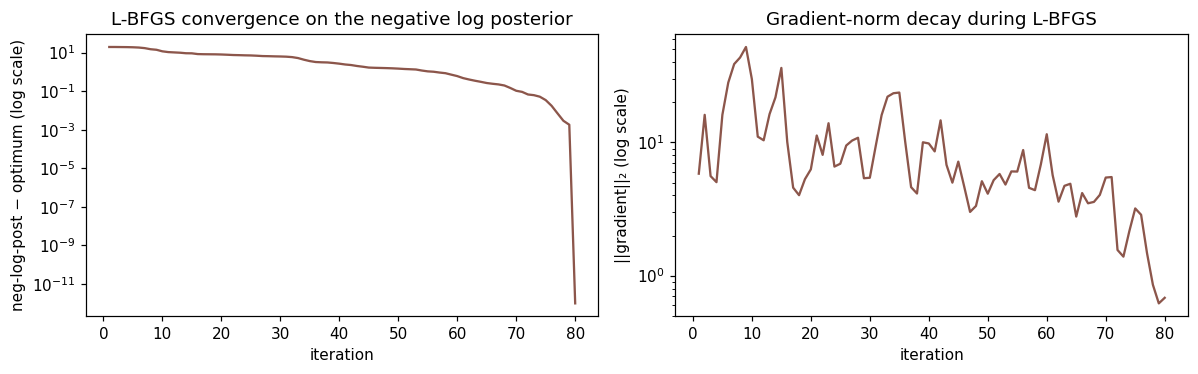

In [3]:
# Run a short manual L-BFGS trace to visualize the descent.
import optax


K = prior.kernel(prior.X, prior.X) + prior.jitter * jnp.eye(N, dtype=jnp.float32)
prior_mean = prior.mean(prior.X)
L_K = jnp.linalg.cholesky(K + 1e-3 * jnp.eye(N, dtype=K.dtype))


def neg_log_post(f):
    ll = lik.log_prob(f, y)
    r = f - prior_mean
    alpha = jax.scipy.linalg.cho_solve((L_K, True), r)
    return -(ll - 0.5 * jnp.dot(r, alpha))


value_and_grad = optax.value_and_grad_from_state(neg_log_post)
opt = optax.lbfgs()
f_curr = jnp.asarray(prior_mean)
state = opt.init(f_curr)
losses = []
grad_norms = []
for it in range(80):
    v, g = value_and_grad(f_curr, state=state)
    losses.append(float(v))
    grad_norms.append(float(jnp.linalg.norm(g)))
    updates, state = opt.update(
        g, state, f_curr, value=v, grad=g, value_fn=neg_log_post
    )
    f_curr = optax.apply_updates(f_curr, updates)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
ax = axes[0]
ax.semilogy(
    np.arange(1, len(losses) + 1), np.asarray(losses) - min(losses) + 1e-12, color="C5"
)
ax.set_xlabel("iteration")
ax.set_ylabel("neg-log-post − optimum (log scale)")
ax.set_title("L-BFGS convergence on the negative log posterior")
ax = axes[1]
ax.semilogy(np.arange(1, len(grad_norms) + 1), grad_norms, color="C5")
ax.set_xlabel("iteration")
ax.set_ylabel("||gradient||₂ (log scale)")
ax.set_title("Gradient-norm decay during L-BFGS")
plt.tight_layout()
plt.show()

Both panels show the typical L-BFGS pattern: rapid early progress, then a long tail of small gradient steps. Newton-based Laplace would hit the noise floor in ~6 iterations rather than ~80.

## Predictive comparison — same posterior, different path

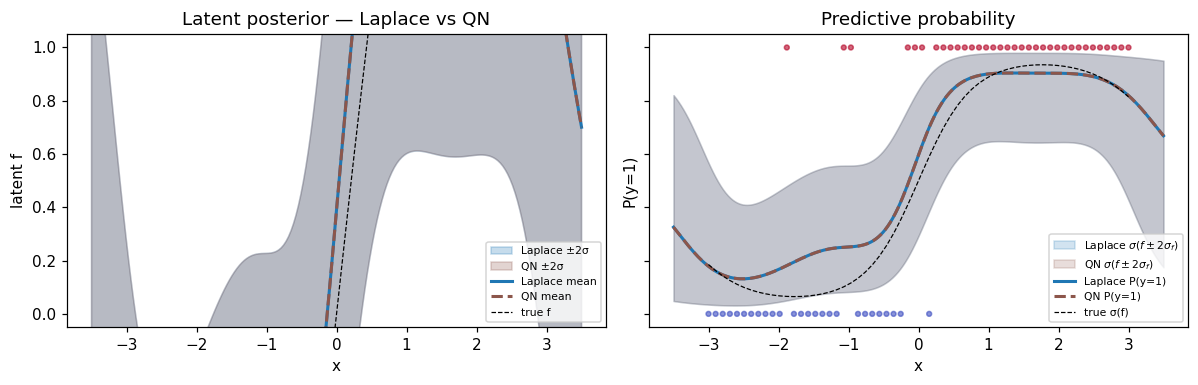

In [4]:
X_star = jnp.linspace(-3.5, 3.5, 200)[:, None]
m_lap, v_lap = cond_lap.predict(X_star)
m_qn, v_qn = cond_qn.predict(X_star)
m_lap, v_lap = np.asarray(m_lap), np.asarray(v_lap)
m_qn, v_qn = np.asarray(m_qn), np.asarray(v_qn)
sd_lap = np.sqrt(np.maximum(v_lap, 0))
sd_qn = np.sqrt(np.maximum(v_qn, 0))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), sharey=True)
ax = axes[0]
ax.fill_between(
    X_star[:, 0],
    m_lap - 2.0 * sd_lap,
    m_lap + 2.0 * sd_lap,
    alpha=0.25,
    color="C0",
    label="Laplace ±2σ",
)
ax.fill_between(
    X_star[:, 0],
    m_qn - 2.0 * sd_qn,
    m_qn + 2.0 * sd_qn,
    alpha=0.25,
    color="C5",
    label="QN ±2σ",
)
ax.plot(X_star[:, 0], m_lap, color="C0", lw=2, label="Laplace mean")
ax.plot(X_star[:, 0], m_qn, color="C5", lw=2, ls="--", label="QN mean")
ax.plot(X[:, 0], f_true, "k--", lw=0.8, label="true f")
ax.set_xlabel("x")
ax.set_ylabel("latent f")
ax.set_title("Latent posterior — Laplace vs QN")
ax.legend(fontsize=7, loc="lower right")

ax = axes[1]
p_lap_mean = jax.nn.sigmoid(m_lap)
p_qn_mean = jax.nn.sigmoid(m_qn)
p_lap_lo = jax.nn.sigmoid(m_lap - 2.0 * sd_lap)
p_lap_hi = jax.nn.sigmoid(m_lap + 2.0 * sd_lap)
p_qn_lo = jax.nn.sigmoid(m_qn - 2.0 * sd_qn)
p_qn_hi = jax.nn.sigmoid(m_qn + 2.0 * sd_qn)
ax.fill_between(
    X_star[:, 0],
    p_lap_lo,
    p_lap_hi,
    alpha=0.20,
    color="C0",
    label=r"Laplace $\sigma(f \pm 2\sigma_f)$",
)
ax.fill_between(
    X_star[:, 0],
    p_qn_lo,
    p_qn_hi,
    alpha=0.20,
    color="C5",
    label=r"QN $\sigma(f \pm 2\sigma_f)$",
)
ax.plot(X_star[:, 0], p_lap_mean, color="C0", lw=2, label="Laplace P(y=1)")
ax.plot(X_star[:, 0], p_qn_mean, color="C5", lw=2, ls="--", label="QN P(y=1)")
ax.plot(X[:, 0], probs_true, "k--", lw=0.8, label="true σ(f)")
ax.scatter(X[:, 0], y, c=y, cmap="coolwarm", s=10, alpha=0.6)
ax.set_xlabel("x")
ax.set_ylabel("P(y=1)")
ax.set_title("Predictive probability")
ax.legend(fontsize=7, loc="lower right")
ax.set_ylim(-0.05, 1.05)
plt.tight_layout()
plt.show()

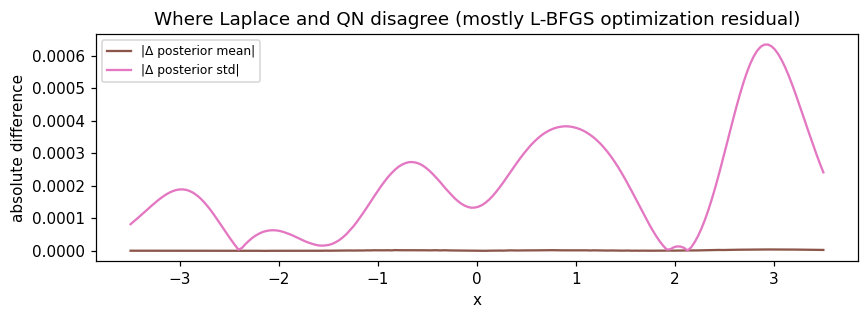

In [5]:
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(X_star[:, 0], np.abs(m_lap - m_qn), label="|Δ posterior mean|", color="C5")
ax.plot(X_star[:, 0], np.abs(sd_lap - sd_qn), label="|Δ posterior std|", color="C6")
ax.set_xlabel("x")
ax.set_ylabel("absolute difference")
ax.set_title("Where Laplace and QN disagree (mostly L-BFGS optimization residual)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

Differences between Laplace and QN are mostly L-BFGS residual error — how close the optimizer got to the true MAP. With more L-BFGS iterations or a tighter tolerance these shrink toward zero.

## Summary

- **QN gives the same Laplace posterior**, just via a gradient-only optimization path.
- **Iteration counts are higher** (typically 5–20× more) but each iteration is cheaper because no per-step Hessian solve is needed.
- **The win is at large $N$** where the $O(N^3)$ Newton step dominates wall time. With an iterative prior solver, QN can scale further than Laplace.
- **Always check `cond.converged`** — L-BFGS can plateau short of the optimum on hard problems. If it doesn't converge, the posterior is still a valid Gaussian approximation centered at the L-BFGS iterate, just not at the MAP.
- **For small or moderate $N$, Laplace is cheaper and tighter.** QN is a scaling-friendly alternative, not a strict improvement.

```python
cond = prior.condition_nongauss(BernoulliLikelihood(), y,
                                strategy=QuasiNewtonInference(max_iter=200, tol=1e-5))
m, v = cond.predict(X_star)
```

This concludes the five-strategy walkthrough. The full picture:

| Strategy | Curvature | Best for |
|---|---|---|
| Laplace | exact Hessian, point | log-concave, small-$N$, mode point estimates |
| Gauss-Newton | PSD-clipped Hessian, point | non-log-concave, want robustness floor |
| Posterior Linearization | cavity-averaged grad/Hessian | between Laplace and EP, IPLF |
| Expectation Propagation | tilted-distribution moments | best calibration, willing to pay for cubature |
| Quasi-Newton | L-BFGS history, Laplace at optimum | large $N$, Hessian solves dominate |